# RL Portfolio Allocation

PPO experiment using the same 50-stock universe, date range, targets, and 61-feature set as `supervised models.ipynb`.

In [2]:
import pandas as pd
from pathlib import Path

DATA_DIR = Path.cwd()
STOCKS_CSV = DATA_DIR / "sp500_stocks.csv"
COMPANIES_CSV = DATA_DIR / "sp500_companies.csv"

assert STOCKS_CSV.exists(), f"Missing {STOCKS_CSV}. Put sp500_stocks.csv in this folder."

# Same 50 large-cap tickers used in supervised models.ipynb
tickers = [
    "NVDA","GOOGL","AAPL","MSFT","AMZN",
    "META","AVGO","TSLA","BRK-B","LLY",
    "JPM","V","XOM","MA","UNH",
    "JNJ","PG","COST","HD","CVX",
    "ABBV","PEP","KO","MRK","CSCO",
    "ADBE","CRM","ORCL","NFLX","WMT",
    "MCD","TMO","AMD","INTC","ACN",
    "IBM","QCOM","TXN","AXP","GS",
    "MS","BLK","SPGI","INTU","BKNG",
    "SBUX","NKE","RTX","LMT","GE"
]

start_date = pd.to_datetime("2016-04-30")
end_date = pd.to_datetime("2026-04-30")

df = pd.read_csv(STOCKS_CSV)
df["date"] = pd.to_datetime(df["date"])

df_filtered = df[
    (df["date"] >= start_date)
    & (df["date"] <= end_date)
    & (df["symbol"].isin(tickers))
].copy()

print(f"Loaded {len(df):,} raw rows from {STOCKS_CSV.name}")
print(f"Filtered rows: {len(df_filtered):,}")
print(f"Symbols: {df_filtered['symbol'].nunique()} / {len(tickers)}")
print(f"Date range: {df_filtered['date'].min()} -> {df_filtered['date'].max()}")
display(df_filtered.head())

Loaded 2,923,060 raw rows from sp500_stocks.csv
Filtered rows: 125,700
Symbols: 50 / 50
Date range: 2016-05-02 00:00:00 -> 2026-04-30 00:00:00


,date,open,high,low,close,volume,symbol
10731,2016-05-02,21.282363,21.307276,20.926789,21.207624,192640400.0,AAPL
10732,2016-05-03,21.334458,21.683238,21.216689,21.556410,227325200.0,AAPL
10733,2016-05-04,21.560934,21.719471,21.248391,21.332190,164102000.0,AAPL
10734,2016-05-05,21.418783,21.434733,21.118009,21.245609,143562000.0,AAPL
10735,2016-05-06,21.275226,21.293453,20.928879,21.127117,174799600.0,AAPL


In [3]:
import numpy as np
import pandas as pd

# ============================================================
# Clean OHLCV + create future targets only
# ============================================================

df_filtered = df_filtered.copy()

# Sort by symbol and date
df_filtered = df_filtered.sort_values(['symbol', 'date']).reset_index(drop=True)

# Make sure numeric
ohlcv_cols = ['open', 'high', 'low', 'close', 'volume']
for col in ohlcv_cols:
    df_filtered[col] = pd.to_numeric(df_filtered[col], errors='coerce')

# Remove old return columns if they already exist
old_return_cols = [
    'log_return',
    'simple_return',
    'simple_return_5d',
    'hist_log_return_1d',
    'hist_simple_return_1d',
    'hist_simple_return_5d',
]
df_filtered = df_filtered.drop(
    columns=[c for c in old_return_cols if c in df_filtered.columns],
    errors='ignore'
)

# ============================================================
# Future close-to-close targets
# Use these as y, never as features
# ============================================================

g_close = df_filtered.groupby('symbol')['close']

df_filtered['target_log_return_t1'] = np.log(g_close.shift(-1) / df_filtered['close'])

df_filtered['target_simple_return_t1'] = (
    g_close.shift(-1) / df_filtered['close'] - 1
)

# Optional: future 5-day close-to-close target
df_filtered['target_simple_return_5d'] = (
    g_close.shift(-5) / df_filtered['close'] - 1
)

print("Only future targets calculated. Current columns:")
print(df_filtered.columns.tolist())

display(df_filtered.head(10))

Only future targets calculated. Current columns:
['date', 'open', 'high', 'low', 'close', 'volume', 'symbol', 'target_log_return_t1', 'target_simple_return_t1', 'target_simple_return_5d']


,date,open,high,low,close,volume,symbol,target_log_return_t1,target_simple_return_t1,target_simple_return_5d
0,2016-05-02,21.282363,21.307276,20.926789,21.207624,192640400.0,AAPL,0.016312,0.016446,-0.003044
1,2016-05-03,21.334458,21.683238,21.216689,21.556410,227325200.0,AAPL,-0.010456,-0.010402,-0.012516
2,2016-05-04,21.560934,21.719471,21.248391,21.332190,164102000.0,AAPL,-0.004067,-0.004059,-0.011856
3,2016-05-05,21.418783,21.434733,21.118009,21.245609,143562000.0,AAPL,-0.005593,-0.005577,-0.031103
4,2016-05-06,21.275226,21.293453,20.928879,21.127117,174799600.0,AAPL,0.000755,0.000755,-0.023727
5,2016-05-09,21.190924,21.366375,21.097501,21.143074,131745600.0,AAPL,0.006766,0.006789,0.011747
6,2016-05-10,21.266113,21.320798,20.988124,21.286619,134747200.0,AAPL,-0.009789,-0.009741,0.000749
7,2016-05-11,21.300293,21.320800,21.067876,21.079269,114876400.0,AAPL,-0.023737,-0.023457,0.022160
8,2016-05-12,21.127119,21.140790,20.386576,20.584812,305258800.0,AAPL,0.001991,0.001993,0.042728
9,2016-05-13,20.507342,20.887866,20.507342,20.625828,177571200.0,AAPL,0.036447,0.037119,0.051923


In [4]:
import numpy as np
import pandas as pd

# ============================================================
# Fast vectorized feature construction
# Target: predict close_t -> close_{t+1}
# No future leakage in features
# ============================================================

df = df_filtered.copy()

# ============================================================
# 0. Basic cleaning / sorting
# ============================================================

df = df.sort_values(['symbol', 'date']).reset_index(drop=True)

for col in ['open', 'high', 'low', 'close', 'volume']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

eps = 1e-8
target_col = 'target_log_return_t1'

if target_col not in df.columns:
    raise ValueError(f"{target_col} not found. Please create future target first.")

g = df.groupby('symbol', sort=False)

# ============================================================
# Helper: fast groupby rolling
# ============================================================

def roll_mean(col, window):
    return (
        df.groupby('symbol', sort=False)[col]
          .rolling(window, min_periods=window)
          .mean()
          .reset_index(level=0, drop=True)
    )

def roll_std(col, window):
    return (
        df.groupby('symbol', sort=False)[col]
          .rolling(window, min_periods=window)
          .std()
          .reset_index(level=0, drop=True)
    )

def roll_sum(col, window):
    return (
        df.groupby('symbol', sort=False)[col]
          .rolling(window, min_periods=window)
          .sum()
          .reset_index(level=0, drop=True)
    )

# ============================================================
# 1. Basic lag variables
# ============================================================

df['prev_close'] = g['close'].shift(1)
df['prev_volume'] = g['volume'].shift(1)

df['price_range'] = df['high'] - df['low']

# Avoid invalid OHLC values
valid_price = (
    (df['open'] > 0)
    & (df['high'] > 0)
    & (df['low'] > 0)
    & (df['close'] > 0)
)

# ============================================================
# 2. Price path structure
# ============================================================

df['pos_close'] = (df['close'] - df['low']) / (df['price_range'] + eps)
df['pos_open'] = (df['open'] - df['low']) / (df['price_range'] + eps)

df['drift_skew'] = (df['close'] - df['open']) / (df['price_range'] + eps)

df['upper_shadow'] = (
    df['high'] - np.maximum(df['open'], df['close'])
) / (df['price_range'] + eps)

df['lower_shadow'] = (
    np.minimum(df['open'], df['close']) - df['low']
) / (df['price_range'] + eps)

df['body_ratio'] = (
    np.abs(df['close'] - df['open']) / (df['price_range'] + eps)
)

# Standard overnight gap: open_t / close_{t-1} - 1
df['gap'] = df['open'] / df['prev_close'] - 1

df['pos_close_delta'] = g['pos_close'].diff()

# Percentage range
df['range'] = df['price_range'] / df['close']
df['range_change'] = g['range'].diff()

# ============================================================
# 3. Volatility structure
# ============================================================

df['parkinson'] = np.where(
    valid_price,
    np.log(df['high'] / df['low']) ** 2,
    np.nan
)

df['gk_vol'] = np.where(
    valid_price,
    0.5 * np.log(df['high'] / df['low']) ** 2
    - (2 * np.log(2) - 1) * np.log(df['close'] / df['open']) ** 2,
    np.nan
)

df['range_mean_5'] = roll_mean('range', 5)
df['range_std_5'] = roll_std('range', 5)

df['range_ratio'] = df['range'] / (df['range_mean_5'] + eps)
df['vol_of_vol'] = df['range_std_5']

# Historical close-to-close return feature: close_{t-1} -> close_t
df['close_jump'] = np.log(df['close'] / df['prev_close'])

df['vol_jump'] = df['volume'] / df['prev_volume'] - 1

# Fast version: remove skew/kurt by default because they are slow and usually unstable
# If you really want them, add them later after the pipeline is stable.
# df['range_skew'] = ...
# df['range_kurt'] = ...

# ============================================================
# 4. Volume microstructure proxies
# ============================================================

df['volume_mean_5'] = roll_mean('volume', 5)
df['volume_std_5'] = roll_std('volume', 5)

df['vol_norm'] = df['volume'] / (df['volume_mean_5'] + eps)
df['vol_z'] = (df['volume'] - df['volume_mean_5']) / (df['volume_std_5'] + eps)

# ------------------------------------------------------------
# Vectorized rolling corr(close, volume)
# corr = cov(close, volume) / (std(close) * std(volume))
# ------------------------------------------------------------

df['close_x_volume'] = df['close'] * df['volume']
df['close_sq'] = df['close'] ** 2
df['volume_sq'] = df['volume'] ** 2

mean_close_5 = roll_mean('close', 5)
mean_volume_5 = roll_mean('volume', 5)
mean_cv_5 = roll_mean('close_x_volume', 5)
mean_close_sq_5 = roll_mean('close_sq', 5)
mean_volume_sq_5 = roll_mean('volume_sq', 5)

cov_cv_5 = mean_cv_5 - mean_close_5 * mean_volume_5
var_close_5 = mean_close_sq_5 - mean_close_5 ** 2
var_volume_5 = mean_volume_sq_5 - mean_volume_5 ** 2

df['price_vol_corr'] = cov_cv_5 / (
    np.sqrt(np.maximum(var_close_5, 0)) * np.sqrt(np.maximum(var_volume_5, 0)) + eps
)

df['up_vol'] = df['volume'] * (df['close'] > df['open']).astype(np.float32)
df['down_vol'] = df['volume'] * (df['close'] <= df['open']).astype(np.float32)

df['vol_imbalance'] = (df['up_vol'] - df['down_vol']) / (df['volume'] + eps)

df['vol_acc'] = g['volume'].diff()
df['vol_acc_ratio'] = df['vol_acc'] / (df['volume'] + eps)

# Symbol-level previous close, no cross-symbol contamination
df['high_vol'] = df['volume'] * (df['close'] > df['prev_close']).astype(np.float32)
df['low_vol'] = df['volume'] * (df['close'] <= df['prev_close']).astype(np.float32)

df['high_vol_ratio'] = df['high_vol'] / (df['volume'] + eps)
df['low_vol_ratio'] = df['low_vol'] / (df['volume'] + eps)

# ============================================================
# 5. Price impact proxies
# ============================================================

df['impact'] = df['close_jump'] / (df['volume'] + eps)
df['signed_impact'] = df['impact']
df['abs_impact'] = np.abs(df['impact'])

df['impact_decay'] = roll_mean('impact', 5)

df['impact_vol_ratio'] = df['impact'] / (df['range'] + eps)

df['return_per_vol'] = df['close_jump'] / (df['vol_norm'] + eps)

# ============================================================
# 6. Liquidity / efficiency
# ============================================================

df['amihud'] = np.abs(df['close_jump']) / (df['volume'] + eps)

df['liquidity_proxy'] = df['volume'] / (df['range'] + eps)

df['close_lag_5'] = g['close'].shift(5)
df['range_sum_5'] = roll_sum('range', 5)

df['efficiency'] = (
    np.abs(df['close'] - df['close_lag_5']) / (df['range_sum_5'] + eps)
)

df['close_jump_mean_5'] = roll_mean('close_jump', 5)
df['close_jump_std_5'] = roll_std('close_jump', 5)

df['trend_strength'] = df['close_jump_mean_5'] / (df['close_jump_std_5'] + eps)

df['reversal_strength'] = -roll_mean('close_jump', 3)

df['noise_ratio'] = df['range_sum_5'] / (
    np.abs(df['close'] - df['close_lag_5']) + eps
)

# ============================================================
# 7. Path asymmetry
# ============================================================

df['up_move'] = (df['high'] - df['open']) / (df['price_range'] + eps)
df['down_move'] = (df['open'] - df['low']) / (df['price_range'] + eps)

df['asymmetry'] = df['up_move'] - df['down_move']

vwap_proxy = (df['high'] + df['low'] + df['close']) / 3

df['close_vs_vwap_proxy'] = (
    df['close'] - vwap_proxy
) / (df['price_range'] + eps)

# ============================================================
# 8. Drop helper columns
# ============================================================

drop_helper_cols = [
    'prev_close',
    'prev_volume',
    'price_range',
    'range_mean_5',
    'range_std_5',
    'volume_mean_5',
    'volume_std_5',
    'close_x_volume',
    'close_sq',
    'volume_sq',
    'close_lag_5',
    'range_sum_5',
    'close_jump_mean_5',
    'close_jump_std_5',
]

df = df.drop(columns=[c for c in drop_helper_cols if c in df.columns], errors='ignore')

# ============================================================
# 9. Define target / feature columns safely
# ============================================================

target_cols = [c for c in df.columns if c.startswith('target_')]

base_cols = [
    'date',
    'symbol',
    'open',
    'high',
    'low',
    'close',
    'volume',
]

feature_cols = [
    c for c in df.columns
    if c not in base_cols
    and c not in target_cols
]

# ============================================================
# 10. Clean model data
# ============================================================

df_model = df.copy()
df_model = df_model.replace([np.inf, -np.inf], np.nan)

# Drop rows with missing target/features
df_model = df_model.dropna(subset=feature_cols + [target_col]).copy()

# ============================================================
# 11. Fast vectorized cross-sectional winsorization by date
# No per-feature groupby loop
# ============================================================

DO_CS_WINSORIZE = True

if DO_CS_WINSORIZE:
    q_low = df_model.groupby('date', sort=False)[feature_cols].quantile(0.01)
    q_high = df_model.groupby('date', sort=False)[feature_cols].quantile(0.99)

    lower = q_low.reindex(df_model['date']).to_numpy()
    upper = q_high.reindex(df_model['date']).to_numpy()

    x = df_model[feature_cols].to_numpy(dtype=np.float64, copy=True)
    x = np.minimum(np.maximum(x, lower), upper)

    df_model.loc[:, feature_cols] = x

# Safety clean after winsorization
df_model = df_model.replace([np.inf, -np.inf], np.nan)
df_model = df_model.dropna(subset=feature_cols + [target_col]).copy()

# Optional: downcast features to float32 to reduce memory
df_model.loc[:, feature_cols] = df_model[feature_cols].astype(np.float32)

# ============================================================
# 12. Final check
# ============================================================

print("Feature construction done.")
print("Total columns in df:", len(df.columns))
print("Number of feature columns:", len(feature_cols))
print("Target columns:", target_cols)
print("Target col:", target_col)
print("df shape:", df.shape)
print("df_model shape:", df_model.shape)

print("\nFeature columns:")
print(feature_cols)

display(df.head(10))
display(df_model.head(10))

# Final X / y
X = df_model[feature_cols]
y = df_model[target_col]

print("\nX shape:", X.shape)
print("y shape:", y.shape)

Feature construction done.
Total columns in df: 54
Number of feature columns: 44
Target columns: ['target_log_return_t1', 'target_simple_return_t1', 'target_simple_return_5d']
Target col: target_log_return_t1
df shape: (125700, 54)
df_model shape: (125400, 54)

Feature columns:
['pos_close', 'pos_open', 'drift_skew', 'upper_shadow', 'lower_shadow', 'body_ratio', 'gap', 'pos_close_delta', 'range', 'range_change', 'parkinson', 'gk_vol', 'range_ratio', 'vol_of_vol', 'close_jump', 'vol_jump', 'vol_norm', 'vol_z', 'price_vol_corr', 'up_vol', 'down_vol', 'vol_imbalance', 'vol_acc', 'vol_acc_ratio', 'high_vol', 'low_vol', 'high_vol_ratio', 'low_vol_ratio', 'impact', 'signed_impact', 'abs_impact', 'impact_decay', 'impact_vol_ratio', 'return_per_vol', 'amihud', 'liquidity_proxy', 'efficiency', 'trend_strength', 'reversal_strength', 'noise_ratio', 'up_move', 'down_move', 'asymmetry', 'close_vs_vwap_proxy']


,date,open,high,low,close,volume,symbol,target_log_return_t1,target_simple_return_t1,target_simple_return_5d,...,amihud,liquidity_proxy,efficiency,trend_strength,reversal_strength,noise_ratio,up_move,down_move,asymmetry,close_vs_vwap_proxy
0,2016-05-02,21.282363,21.307276,20.926789,21.207624,192640400.0,AAPL,0.016312,0.016446,-0.003044,...,NaN,1.073740e+10,NaN,NaN,NaN,NaN,0.065477,0.934523,-0.869047,0.158729
1,2016-05-03,21.334458,21.683238,21.216689,21.556410,227325200.0,AAPL,-0.010456,-0.010402,-0.012516,...,7.175822e-11,1.050331e+10,NaN,NaN,NaN,NaN,0.747574,0.252426,0.495148,0.152104
2,2016-05-04,21.560934,21.719471,21.248391,21.332190,164102000.0,AAPL,-0.004067,-0.004059,-0.011856,...,6.371667e-11,7.431128e+09,NaN,NaN,NaN,NaN,0.336540,0.663460,-0.326919,-0.214743
3,2016-05-05,21.418783,21.434733,21.118009,21.245609,143562000.0,AAPL,-0.005593,-0.005577,-0.031103,...,2.832871e-11,9.630013e+09,NaN,NaN,-0.000596,NaN,0.050360,0.949640,-0.899281,-0.064749
4,2016-05-06,21.275226,21.293453,20.928879,21.127117,174799600.0,AAPL,0.000755,0.000755,-0.023727,...,3.199586e-11,1.012964e+10,NaN,NaN,0.006705,NaN,0.049996,0.950004,-0.900007,0.029168
5,2016-05-09,21.190924,21.366375,21.097501,21.143074,131745600.0,AAPL,0.006766,0.006789,0.011747,...,5.730699e-12,1.035988e+10,0.728501,-0.059360,0.002968,1.372681,0.652539,0.347461,0.305079,-0.220336
6,2016-05-10,21.266113,21.320798,20.988124,21.286619,134747200.0,AAPL,-0.009789,-0.009741,0.000749,...,5.021466e-11,8.621975e+09,3.266536,-0.384379,-0.000643,0.306135,0.164382,0.835618,-0.671236,0.264839
7,2016-05-11,21.300293,21.320800,21.067876,21.079269,114876400.0,AAPL,-0.023737,-0.023457,0.022160,...,8.520987e-11,9.574055e+09,3.488172,-0.375368,0.000756,0.286683,0.081078,0.918922,-0.837844,-0.303301
8,2016-05-12,21.127119,21.140790,20.386576,20.584812,305258800.0,AAPL,0.001991,0.001993,0.042728,...,7.775872e-11,8.331448e+09,7.011890,-0.545297,0.008920,0.142615,0.018126,0.981874,-0.963748,-0.158108
9,2016-05-13,20.507342,20.887866,20.507342,20.625828,177571200.0,AAPL,0.036447,0.037119,0.051923,...,1.120979e-11,9.625002e+09,5.252831,-0.394036,0.010512,0.190374,1.000000,0.000000,1.000000,-0.125750


,date,open,high,low,close,volume,symbol,target_log_return_t1,target_simple_return_t1,target_simple_return_5d,...,amihud,liquidity_proxy,efficiency,trend_strength,reversal_strength,noise_ratio,up_move,down_move,asymmetry,close_vs_vwap_proxy
5,2016-05-09,21.190924,21.366375,21.097501,21.143074,131745600.0,AAPL,0.006766,0.006789,0.011747,...,5.730699e-12,1.035988e+10,0.728501,-0.059360,0.002968,1.372681,0.652539,0.347461,0.305079,-0.220336
6,2016-05-10,21.266113,21.320798,20.988124,21.286619,134747200.0,AAPL,-0.009789,-0.009741,0.000749,...,5.021466e-11,8.621975e+09,3.266536,-0.384379,-0.000643,0.306135,0.165501,0.834499,-0.668997,0.264839
7,2016-05-11,21.300293,21.320800,21.067876,21.079269,114876400.0,AAPL,-0.023737,-0.023457,0.022160,...,8.520987e-11,9.574055e+09,3.488172,-0.375368,0.000756,0.286683,0.081078,0.918922,-0.837844,-0.303301
8,2016-05-12,21.127119,21.140790,20.386576,20.584812,305258800.0,AAPL,0.001991,0.001993,0.042728,...,7.775872e-11,8.331448e+09,7.011889,-0.492415,0.008920,0.142615,0.018126,0.981874,-0.963748,-0.158108
9,2016-05-13,20.507342,20.887866,20.507342,20.625828,177571200.0,AAPL,0.036447,0.037119,0.051923,...,1.246837e-11,9.625002e+09,5.252831,-0.394036,0.010512,0.190373,0.982373,0.017627,0.964746,-0.125750
10,2016-05-16,21.051935,21.507654,20.883320,21.391445,245039200.0,AAPL,-0.004163,-0.004155,0.027162,...,1.487395e-10,8.395726e+09,2.219551,0.104195,-0.004900,0.450541,0.729928,0.270072,0.459855,0.209245
11,2016-05-17,21.544102,21.578280,21.193199,21.302570,187667600.0,AAPL,0.011380,0.011445,0.047171,...,2.218467e-11,1.038171e+10,0.139494,0.006685,-0.011425,7.168749,0.088754,0.911246,-0.822492,-0.143985
12,2016-05-18,21.455241,21.694492,21.393718,21.546383,168249600.0,AAPL,-0.003814,-0.003807,0.053511,...,6.763889e-11,1.205278e+10,4.016087,0.198714,-0.014555,0.248999,0.795451,0.204549,0.590903,0.005050
13,2016-05-19,21.564612,21.564612,21.320803,21.464354,121768400.0,AAPL,0.010770,0.010828,0.065924,...,3.132480e-11,1.072016e+10,9.662098,0.494892,-0.001134,0.103497,0.000000,1.000000,-1.000000,0.059188
14,2016-05-20,21.564617,21.744626,21.537273,21.696775,128104000.0,AAPL,0.012627,0.012707,0.053875,...,8.407284e-11,1.340440e+10,13.038398,0.612362,-0.006112,0.076697,0.868129,0.131871,0.736259,0.179488



X shape: (125400, 44)
y shape: (125400,)


In [5]:
import numpy as np
import pandas as pd

# ============================================================
# Add selected GP formula factors into df_model
# Source: selected decoded GP formulas
# ============================================================

df_model = df_model.copy()

eps = 1e-8

def softsign(x):
    return x / (1.0 + np.abs(x))

def safe_div(x, y):
    return x / (y + eps)

# ============================================================
# Required raw feature columns
# ============================================================

required_cols = [
    "close_vs_vwap_proxy",
    "pos_close",
    "pos_open",
    "pos_close_delta",
    "upper_shadow",
    "drift_skew",
    "vol_acc_ratio",
    "vol_norm",
    "low_vol_ratio",
    "high_vol",
    "down_vol",
    "vol_jump",
    "price_vol_corr",
    "range_change",
    "return_per_vol",
    "amihud",
    "impact_vol_ratio",
    "close_jump",
    "noise_ratio",
    "reversal_strength",
]

missing_cols = [c for c in required_cols if c not in df_model.columns]
assert len(missing_cols) == 0, f"Missing columns in df_model: {missing_cols}"

# ============================================================
# Previously selected simple GP factors
# ============================================================

# softsign(neg(close_vs_vwap_proxy))
df_model["gp_factor_softsign_neg_close_vs_vwap"] = softsign(
    -df_model["close_vs_vwap_proxy"]
)

# neg(pos_close)
df_model["gp_factor_neg_pos_close"] = -df_model["pos_close"]

# sub(add(neg(pos_close), vol_acc_ratio), pos_close)
# = vol_acc_ratio - 2 * pos_close
df_model["gp_factor_vol_acc_minus_2_pos_close"] = (
    df_model["vol_acc_ratio"] - 2.0 * df_model["pos_close"]
)

# sub(add(tanh(neg(pos_close)), vol_acc_ratio), pos_close)
# = tanh(-pos_close) + vol_acc_ratio - pos_close
df_model["gp_factor_tanh_neg_pos_close_vol_acc"] = (
    np.tanh(-df_model["pos_close"])
    + df_model["vol_acc_ratio"]
    - df_model["pos_close"]
)

# ============================================================
# New GP factors from current selected table
# ============================================================

# 1. sub(tanh(X3), X33)
# = tanh(upper_shadow) - return_per_vol
df_model["gp_factor_tanh_upper_shadow_minus_return_per_vol"] = (
    np.tanh(df_model["upper_shadow"])
    - df_model["return_per_vol"]
)

# 2. add(softsign(add(mul(X27, X16), tanh(X3))), X3)
# = softsign(low_vol_ratio * vol_norm + tanh(upper_shadow)) + upper_shadow
df_model["gp_factor_lowvol_volnorm_upper_shadow"] = (
    softsign(
        df_model["low_vol_ratio"] * df_model["vol_norm"]
        + np.tanh(df_model["upper_shadow"])
    )
    + df_model["upper_shadow"]
)

# 3. add(sub(X3, X43), mul(mul(neg(X0), X39), tanh(mul(-0.586, X0))))
# = upper_shadow - close_vs_vwap_proxy
#   + (-pos_close) * noise_ratio * tanh(-0.586 * pos_close)
df_model["gp_factor_upper_minus_vwap_pos_noise"] = (
    df_model["upper_shadow"]
    - df_model["close_vs_vwap_proxy"]
    + (
        -df_model["pos_close"]
        * df_model["noise_ratio"]
        * np.tanh(-0.586 * df_model["pos_close"])
    )
)

# 4. add(sub(X3, X43), mul(mul(tanh(sub(X24, X15)), sub(X23, X2)), X3))
# = upper_shadow - close_vs_vwap_proxy
#   + tanh(high_vol - vol_jump) * (vol_acc_ratio - drift_skew) * upper_shadow
df_model["gp_factor_upper_vwap_highvol_volacc_drift"] = (
    df_model["upper_shadow"]
    - df_model["close_vs_vwap_proxy"]
    + (
        np.tanh(df_model["high_vol"] - df_model["vol_jump"])
        * (df_model["vol_acc_ratio"] - df_model["drift_skew"])
        * df_model["upper_shadow"]
    )
)

# 5. add(softsign(softsign(X3)), X38)
# = softsign(softsign(upper_shadow)) + reversal_strength
df_model["gp_factor_upper_softsign_reversal"] = (
    softsign(softsign(df_model["upper_shadow"]))
    + df_model["reversal_strength"]
)

# 6. sub(sub(X3, neg(X34)), tanh(mul(mul(X1, X7), neg(softsign(X43)))))
# = upper_shadow + amihud
#   - tanh(pos_open * pos_close_delta * -softsign(close_vs_vwap_proxy))
df_model["gp_factor_upper_amihud_posopen_delta_vwap"] = (
    df_model["upper_shadow"]
    + df_model["amihud"]
    - np.tanh(
        df_model["pos_open"]
        * df_model["pos_close_delta"]
        * (-softsign(df_model["close_vs_vwap_proxy"]))
    )
)

# 7. add(X3, sub(softsign(X3), X43))
# = upper_shadow + softsign(upper_shadow) - close_vs_vwap_proxy
df_model["gp_factor_upper_softsign_minus_vwap"] = (
    df_model["upper_shadow"]
    + softsign(df_model["upper_shadow"])
    - df_model["close_vs_vwap_proxy"]
)

# 8. add(sub(X3, X43), mul(mul(tanh(sub(X24, neg(X18))), X39), X3))
# = upper_shadow - close_vs_vwap_proxy
#   + tanh(high_vol + price_vol_corr) * noise_ratio * upper_shadow
df_model["gp_factor_upper_vwap_highvol_corr_noise"] = (
    df_model["upper_shadow"]
    - df_model["close_vs_vwap_proxy"]
    + (
        np.tanh(df_model["high_vol"] + df_model["price_vol_corr"])
        * df_model["noise_ratio"]
        * df_model["upper_shadow"]
    )
)

# 9. sub(X27, softsign(softsign(sub(X9, softsign(X3)))))
# = low_vol_ratio - softsign(softsign(range_change - softsign(upper_shadow)))
df_model["gp_factor_lowvol_range_upper"] = (
    df_model["low_vol_ratio"]
    - softsign(
        softsign(
            df_model["range_change"]
            - softsign(df_model["upper_shadow"])
        )
    )
)

# 10. softsign(sub(X3, sub(X32, softsign(sub(X14, X43)))))
# = softsign(upper_shadow - impact_vol_ratio
#             + softsign(close_jump - close_vs_vwap_proxy))
df_model["gp_factor_upper_impact_closejump_vwap"] = softsign(
    df_model["upper_shadow"]
    - df_model["impact_vol_ratio"]
    + softsign(
        df_model["close_jump"]
        - df_model["close_vs_vwap_proxy"]
    )
)

# 11. add(tanh(X27), softsign(X3))
# = tanh(low_vol_ratio) + softsign(upper_shadow)
df_model["gp_factor_tanh_lowvol_softsign_upper"] = (
    np.tanh(df_model["low_vol_ratio"])
    + softsign(df_model["upper_shadow"])
)

# 12. sub(add(add(tanh(tanh(div(X20, X39))), tanh(tanh(X3))), X3), X43)
# = tanh(tanh(down_vol / noise_ratio))
#   + tanh(tanh(upper_shadow))
#   + upper_shadow
#   - close_vs_vwap_proxy
df_model["gp_factor_downvol_noise_upper_vwap"] = (
    np.tanh(np.tanh(safe_div(df_model["down_vol"], df_model["noise_ratio"])))
    + np.tanh(np.tanh(df_model["upper_shadow"]))
    + df_model["upper_shadow"]
    - df_model["close_vs_vwap_proxy"]
)

# 13. add(X38, tanh(sub(X3, softsign(X3))))
# = reversal_strength + tanh(upper_shadow - softsign(upper_shadow))
df_model["gp_factor_reversal_upper_tanh"] = (
    df_model["reversal_strength"]
    + np.tanh(
        df_model["upper_shadow"]
        - softsign(df_model["upper_shadow"])
    )
)

# ============================================================
# Clean GP factors
# ============================================================

gp_factor_cols = [
    "gp_factor_softsign_neg_close_vs_vwap",
    "gp_factor_neg_pos_close",
    "gp_factor_vol_acc_minus_2_pos_close",
    "gp_factor_tanh_neg_pos_close_vol_acc",

    "gp_factor_tanh_upper_shadow_minus_return_per_vol",
    "gp_factor_lowvol_volnorm_upper_shadow",
    "gp_factor_upper_minus_vwap_pos_noise",
    "gp_factor_upper_vwap_highvol_volacc_drift",
    "gp_factor_upper_softsign_reversal",
    "gp_factor_upper_amihud_posopen_delta_vwap",
    "gp_factor_upper_softsign_minus_vwap",
    "gp_factor_upper_vwap_highvol_corr_noise",
    "gp_factor_lowvol_range_upper",
    "gp_factor_upper_impact_closejump_vwap",
    "gp_factor_tanh_lowvol_softsign_upper",
    "gp_factor_downvol_noise_upper_vwap",
    "gp_factor_reversal_upper_tanh",
]

df_model[gp_factor_cols] = df_model[gp_factor_cols].replace([np.inf, -np.inf], np.nan)

# Optional: fill remaining nan with 0, or keep nan and drop later.
# For strict modeling, usually keep nan and drop in df_model_final.
# df_model[gp_factor_cols] = df_model[gp_factor_cols].fillna(0.0)

# ============================================================
# Update feature_cols
# ============================================================

if "feature_cols" in globals():
    feature_cols = list(feature_cols)
    for c in gp_factor_cols:
        if c not in feature_cols:
            feature_cols.append(c)

print("Added GP factor columns:", len(gp_factor_cols))
print(gp_factor_cols)

display(df_model[["date", "symbol"] + gp_factor_cols].head(10))

Added GP factor columns: 17
['gp_factor_softsign_neg_close_vs_vwap', 'gp_factor_neg_pos_close', 'gp_factor_vol_acc_minus_2_pos_close', 'gp_factor_tanh_neg_pos_close_vol_acc', 'gp_factor_tanh_upper_shadow_minus_return_per_vol', 'gp_factor_lowvol_volnorm_upper_shadow', 'gp_factor_upper_minus_vwap_pos_noise', 'gp_factor_upper_vwap_highvol_volacc_drift', 'gp_factor_upper_softsign_reversal', 'gp_factor_upper_amihud_posopen_delta_vwap', 'gp_factor_upper_softsign_minus_vwap', 'gp_factor_upper_vwap_highvol_corr_noise', 'gp_factor_lowvol_range_upper', 'gp_factor_upper_impact_closejump_vwap', 'gp_factor_tanh_lowvol_softsign_upper', 'gp_factor_downvol_noise_upper_vwap', 'gp_factor_reversal_upper_tanh']


,date,symbol,gp_factor_softsign_neg_close_vs_vwap,gp_factor_neg_pos_close,gp_factor_vol_acc_minus_2_pos_close,gp_factor_tanh_neg_pos_close_vol_acc,gp_factor_tanh_upper_shadow_minus_return_per_vol,gp_factor_lowvol_volnorm_upper_shadow,gp_factor_upper_minus_vwap_pos_noise,gp_factor_upper_vwap_highvol_volacc_drift,gp_factor_upper_softsign_reversal,gp_factor_upper_amihud_posopen_delta_vwap,gp_factor_upper_softsign_minus_vwap,gp_factor_upper_vwap_highvol_corr_noise,gp_factor_lowvol_range_upper,gp_factor_upper_impact_closejump_vwap,gp_factor_tanh_lowvol_softsign_upper,gp_factor_downvol_noise_upper_vwap,gp_factor_reversal_upper_tanh
5,2016-05-09,AAPL,0.180554,-0.169495,-0.665787,-0.664183,0.572412,1.016964,0.895909,0.775758,0.286056,0.676014,1.267746,1.768604,0.222040,0.454625,0.394871,2.152305,0.255082
6,2016-05-10,AAPL,-0.209386,-0.897259,-1.772242,-1.589944,0.094859,0.195613,-0.029658,-0.166143,0.084585,0.229224,-0.068930,-0.130646,0.076456,-0.092882,0.093169,-0.060074,0.008929
7,2016-05-11,AAPL,0.232718,-0.045048,-0.263071,-0.263041,0.092825,0.555250,0.384720,0.392699,0.070521,0.261332,0.459376,0.386406,1.067943,0.235468,0.836591,1.226698,0.006836
8,2016-05-12,AAPL,0.136522,-0.262839,0.042581,0.048471,0.031521,0.659696,0.181962,0.155945,0.026412,-0.011060,0.194037,0.174365,0.993255,0.120168,0.779398,0.955950,0.009242
9,2016-05-13,AAPL,0.111703,-0.311376,-1.341829,-1.332142,0.595160,1.062489,0.825072,0.104778,0.300184,0.688529,1.222176,0.945470,0.230019,0.445029,0.407802,1.349355,0.284178
10,2016-05-16,AAPL,-0.173038,-0.813868,-1.352400,-1.210250,0.156429,0.341546,0.139612,-0.073082,0.130738,0.209611,0.133811,0.060748,0.113115,0.035935,0.156924,0.158850,0.024300
11,2016-05-17,AAPL,0.125863,-0.284022,-0.873753,-0.866354,0.093094,0.588545,0.568524,0.239301,0.063950,0.149448,0.314258,0.071498,1.078150,0.174525,0.843113,1.082625,-0.004190
12,2016-05-18,AAPL,-0.005024,-0.507574,-1.130561,-1.091040,0.441478,0.805678,0.523897,0.281326,0.233537,0.492655,0.817326,0.609989,0.200264,0.332762,0.329950,0.914308,0.146506
13,2016-05-19,AAPL,-0.055881,-0.588783,-1.559283,-1.499520,0.005640,0.403437,-0.038960,-0.059188,-0.001134,0.004538,-0.059188,-0.059188,1.002587,-0.055952,0.761594,0.702406,-0.001134
14,2016-05-20,AAPL,-0.152175,-0.769233,-1.489009,-1.366259,0.212450,0.415609,0.076207,-0.084391,0.151782,0.234388,0.238778,0.068978,0.137314,0.079533,0.187499,0.274227,0.037130


## PPO Setup

Long-only, fully invested allocation across all 50 stocks. Actions are converted to weights with softmax, so weights are non-negative and sum to 1. Reward is daily net portfolio return after `5 bps * turnover`.

In [6]:
import importlib.util

missing = [pkg for pkg in ["gymnasium", "stable_baselines3"] if importlib.util.find_spec(pkg) is None]
if missing:
    print("Missing packages:", missing)
    print("Run this in a notebook cell, then restart the kernel:")
    print("%pip install gymnasium stable-baselines3")
else:
    print("RL dependencies are installed.")

RL dependencies are installed.


In [7]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import gymnasium as gym
from gymnasium import spaces

from sklearn.preprocessing import StandardScaler
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.callbacks import EvalCallback, StopTrainingOnNoModelImprovement

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

TARGET_COL = "target_simple_return_t1"
DATE_COL = "date"
SYMBOL_COL = "symbol"
COST_BPS = 5
ANN_FACTOR = 252

# Exact 61-feature manually assembled set used by the supervised neural models.
feature_cols = [
    "pos_close", "pos_open", "drift_skew",
    "upper_shadow", "lower_shadow", "body_ratio", "gap", "pos_close_delta",
    "range", "range_change", "parkinson", "gk_vol", "range_ratio",
    "vol_of_vol", "close_jump", "vol_jump", "vol_norm", "vol_z",
    "price_vol_corr", "up_vol", "down_vol", "vol_imbalance", "vol_acc",
    "vol_acc_ratio", "high_vol", "low_vol", "high_vol_ratio",
    "low_vol_ratio", "impact", "signed_impact", "abs_impact",
    "impact_decay", "impact_vol_ratio", "return_per_vol", "amihud",
    "liquidity_proxy", "efficiency", "trend_strength", "reversal_strength",
    "noise_ratio", "up_move", "down_move", "asymmetry",
    "close_vs_vwap_proxy",
    "gp_factor_softsign_neg_close_vs_vwap",
    "gp_factor_neg_pos_close",
    "gp_factor_vol_acc_minus_2_pos_close",
    "gp_factor_tanh_neg_pos_close_vol_acc",
    "gp_factor_tanh_upper_shadow_minus_return_per_vol",
    "gp_factor_lowvol_volnorm_upper_shadow",
    "gp_factor_upper_minus_vwap_pos_noise",
    "gp_factor_upper_vwap_highvol_volacc_drift",
    "gp_factor_upper_softsign_reversal",
    "gp_factor_upper_amihud_posopen_delta_vwap",
    "gp_factor_upper_softsign_minus_vwap",
    "gp_factor_upper_vwap_highvol_corr_noise",
    "gp_factor_lowvol_range_upper",
    "gp_factor_upper_impact_closejump_vwap",
    "gp_factor_tanh_lowvol_softsign_upper",
    "gp_factor_downvol_noise_upper_vwap",
    "gp_factor_reversal_upper_tanh",
]

missing_features = [c for c in feature_cols if c not in df_model.columns]
assert not missing_features, f"Missing feature columns: {missing_features}"
assert TARGET_COL in df_model.columns
assert len(feature_cols) == 61

rl_df = df_model.copy()
rl_df[DATE_COL] = pd.to_datetime(rl_df[DATE_COL])
rl_df = rl_df.sort_values([SYMBOL_COL, DATE_COL]).reset_index(drop=True)

# target_date is the date when target_simple_return_t1 is realized.
rl_df["target_date"] = rl_df.groupby(SYMBOL_COL)[DATE_COL].shift(-1)
rl_df = rl_df.replace([np.inf, -np.inf], np.nan)

unique_target_dates = np.array(sorted(rl_df["target_date"].dropna().unique()))
train_end = int(len(unique_target_dates) * 0.70)
val_end = int(len(unique_target_dates) * 0.85)
train_dates = unique_target_dates[:train_end]
valid_dates = unique_target_dates[train_end:val_end]
test_dates = unique_target_dates[val_end:]

print("Split by target_date:")
print("Train:", pd.to_datetime(train_dates[0]), "->", pd.to_datetime(train_dates[-1]), len(train_dates))
print("Valid:", pd.to_datetime(valid_dates[0]), "->", pd.to_datetime(valid_dates[-1]), len(valid_dates))
print("Test :", pd.to_datetime(test_dates[0]), "->", pd.to_datetime(test_dates[-1]), len(test_dates))

# Fit scaler on train only, matching the no-leakage supervised setup.
train_mask = rl_df["target_date"].isin(train_dates)
scaler_df = rl_df.loc[train_mask, feature_cols].copy()
scaler_df = scaler_df.replace([np.inf, -np.inf], np.nan)
global_median = scaler_df.median(numeric_only=True)
scaler_df = scaler_df.fillna(global_median).fillna(0.0)

x_scaler = StandardScaler()
x_scaler.fit(scaler_df.values)

rl_df[feature_cols] = rl_df[feature_cols].replace([np.inf, -np.inf], np.nan)
rl_df[feature_cols] = (
    rl_df.groupby(SYMBOL_COL, sort=False)[feature_cols]
         .ffill()
)
rl_df[feature_cols] = rl_df[feature_cols].fillna(global_median).fillna(0.0)
rl_df[feature_cols] = x_scaler.transform(rl_df[feature_cols].values)

# Keep only complete 50-stock panels so the action dimension is stable.
universe = list(tickers)
N_ASSETS = len(universe)
N_FEATURES = len(feature_cols)

def make_panel(df, target_dates):
    part = df[df["target_date"].isin(target_dates)].copy()
    part = part.dropna(subset=feature_cols + [TARGET_COL, "target_date"])

    usable_dates = []
    X_list, R_list, source_dates, target_date_list = [], [], [], []

    for dt, g in part.groupby(DATE_COL, sort=True):
        g = g[g[SYMBOL_COL].isin(universe)].copy()
        if g[SYMBOL_COL].nunique() != N_ASSETS:
            continue
        g = g.set_index(SYMBOL_COL).reindex(universe)
        if g[feature_cols + [TARGET_COL, "target_date"]].isna().any().any():
            continue
        X_list.append(g[feature_cols].values.astype(np.float32))
        R_list.append(g[TARGET_COL].values.astype(np.float32))
        source_dates.append(pd.Timestamp(dt))
        target_date_list.append(pd.Timestamp(g["target_date"].iloc[0]))
        usable_dates.append(dt)

    return {
        "X": np.stack(X_list),
        "returns": np.stack(R_list),
        "source_dates": np.array(source_dates),
        "target_dates": np.array(target_date_list),
        "symbols": universe,
    }

train_panel = make_panel(rl_df, train_dates)
valid_panel = make_panel(rl_df, valid_dates)
test_panel = make_panel(rl_df, test_dates)

print("Panel shapes:")
print("Train X:", train_panel["X"].shape, "returns:", train_panel["returns"].shape)
print("Valid X:", valid_panel["X"].shape, "returns:", valid_panel["returns"].shape)
print("Test  X:", test_panel["X"].shape, "returns:", test_panel["returns"].shape)

Split by target_date:
Train: 2016-05-10 00:00:00 -> 2023-04-27 00:00:00 1754
Valid: 2023-04-28 00:00:00 -> 2024-10-24 00:00:00 376
Test : 2024-10-25 00:00:00 -> 2026-04-29 00:00:00 377
Panel shapes:
Train X: (1754, 50, 61) returns: (1754, 50)
Valid X: (376, 50, 61) returns: (376, 50)
Test  X: (377, 50, 61) returns: (377, 50)


In [8]:
class PortfolioAllocationEnv(gym.Env):
    """Long-only, fully invested daily allocation env.

    Observation: flattened 50 x 61 feature panel plus previous 50-stock weights.
    Action: 50 unconstrained logits, converted to long-only weights with softmax.
    Reward: next-day net portfolio simple return after transaction cost.
    """

    metadata = {"render_modes": []}

    def __init__(self, panel, cost_bps=5, initial_weights="equal"):
        super().__init__()
        self.X = panel["X"].astype(np.float32)
        self.returns = panel["returns"].astype(np.float32)
        self.source_dates = panel["source_dates"]
        self.target_dates = panel["target_dates"]
        self.symbols = panel["symbols"]
        self.cost_bps = float(cost_bps)
        self.initial_weights = initial_weights

        self.n_steps, self.n_assets, self.n_features = self.X.shape
        obs_dim = self.n_assets * self.n_features + self.n_assets

        self.observation_space = spaces.Box(
            low=-np.inf,
            high=np.inf,
            shape=(obs_dim,),
            dtype=np.float32,
        )
        self.action_space = spaces.Box(
            low=-10.0,
            high=10.0,
            shape=(self.n_assets,),
            dtype=np.float32,
        )

        self.reset()

    def _initial_weights(self):
        return np.full(self.n_assets, 1.0 / self.n_assets, dtype=np.float32)

    @staticmethod
    def _softmax(action):
        action = np.asarray(action, dtype=np.float64)
        action = action - np.max(action)
        exp_action = np.exp(action)
        weights = exp_action / (exp_action.sum() + 1e-12)
        return weights.astype(np.float32)

    def _get_obs(self):
        features = self.X[self.idx].reshape(-1)
        return np.concatenate([features, self.prev_weights], axis=0).astype(np.float32)

    def reset(self, *, seed=None, options=None):
        super().reset(seed=seed)
        self.idx = 0
        self.prev_weights = self._initial_weights()
        self.nav = 1.0
        return self._get_obs(), {}

    def step(self, action):
        weights = self._softmax(action)
        asset_returns = self.returns[self.idx]

        gross_return = float(np.dot(weights, asset_returns))
        turnover = float(np.abs(weights - self.prev_weights).sum())
        cost = turnover * self.cost_bps / 10000.0
        net_return = gross_return - cost

        self.nav *= (1.0 + net_return)

        info = {
            "source_date": self.source_dates[self.idx],
            "target_date": self.target_dates[self.idx],
            "gross_return": gross_return,
            "turnover": turnover,
            "cost": cost,
            "net_return": net_return,
            "nav": self.nav,
            "weights": weights.copy(),
        }

        self.prev_weights = weights
        self.idx += 1
        terminated = self.idx >= self.n_steps
        truncated = False

        if terminated:
            obs = np.zeros(self.observation_space.shape, dtype=np.float32)
        else:
            obs = self._get_obs()

        return obs, net_return, terminated, truncated, info


def make_env(panel, cost_bps=COST_BPS):
    return Monitor(PortfolioAllocationEnv(panel, cost_bps=cost_bps))

train_env = DummyVecEnv([lambda: make_env(train_panel)])
valid_env = DummyVecEnv([lambda: make_env(valid_panel)])
print("Environment ready.")

Environment ready.


In [9]:
MODEL_DIR = "./rl_ppo_all50_long_only"
os.makedirs(MODEL_DIR, exist_ok=True)

policy_kwargs = dict(net_arch=dict(pi=[256, 128], vf=[256, 128]))

stop_callback = StopTrainingOnNoModelImprovement(
    max_no_improvement_evals=8,
    min_evals=5,
    verbose=1,
)

eval_callback = EvalCallback(
    valid_env,
    best_model_save_path=MODEL_DIR,
    log_path=MODEL_DIR,
    eval_freq=5_000,
    n_eval_episodes=1,
    deterministic=True,
    callback_after_eval=stop_callback,
    verbose=1,
)

model = PPO(
    "MlpPolicy",
    train_env,
    learning_rate=3e-4,
    n_steps=512,
    batch_size=256,
    n_epochs=10,
    gamma=0.99,
    gae_lambda=0.95,
    clip_range=0.2,
    ent_coef=0.001,
    vf_coef=0.5,
    max_grad_norm=0.5,
    policy_kwargs=policy_kwargs,
    seed=SEED,
    verbose=1,
)

# Increase total_timesteps after the first smoke test if training is stable.
TOTAL_TIMESTEPS = 100_000
model.learn(total_timesteps=TOTAL_TIMESTEPS, callback=eval_callback)
model.save(os.path.join(MODEL_DIR, "ppo_all50_long_only_final"))
print("Saved PPO model to", MODEL_DIR)

Using cpu device
-----------------------------
| time/              |      |
|    fps             | 4447 |
|    iterations      | 1    |
|    time_elapsed    | 0    |
|    total_timesteps | 512  |
-----------------------------
----------------------------------------
| time/                   |            |
|    fps                  | 2377       |
|    iterations           | 2          |
|    time_elapsed         | 0          |
|    total_timesteps      | 1024       |
| train/                  |            |
|    approx_kl            | 0.12747762 |
|    clip_fraction        | 0.603      |
|    clip_range           | 0.2        |
|    entropy_loss         | -70.9      |
|    explained_variance   | -9.51      |
|    learning_rate        | 0.0003     |
|    loss                 | -0.224     |
|    n_updates            | 10         |
|    policy_gradient_loss | -0.128     |
|    std                  | 1          |
|    value_loss           | 0.107      |
-----------------------------------

Loaded best validation PPO model: ./rl_ppo_all50_long_only/best_model.zip


,strategy,start_date,end_date,days,total_return,ann_return,ann_vol,sharpe,max_drawdown,win_rate,avg_turnover,avg_cost
1,EqualWeight50_valid,2023-04-28,2024-10-24,376,0.503969,0.314582,0.119026,2.642971,-0.085556,0.585106,0.000000,0.000000
0,PPO_All50_LongOnly_valid,2023-04-28,2024-10-24,376,0.483267,0.302427,0.118753,2.546695,-0.088166,0.579787,0.089368,0.000045
3,EqualWeight50_test,2024-10-25,2026-04-29,377,0.239214,0.154150,0.165827,0.929583,-0.181201,0.567639,0.000000,0.000000
2,PPO_All50_LongOnly_test,2024-10-25,2026-04-29,377,0.219822,0.142046,0.166140,0.854974,-0.184172,0.562334,0.090512,0.000045


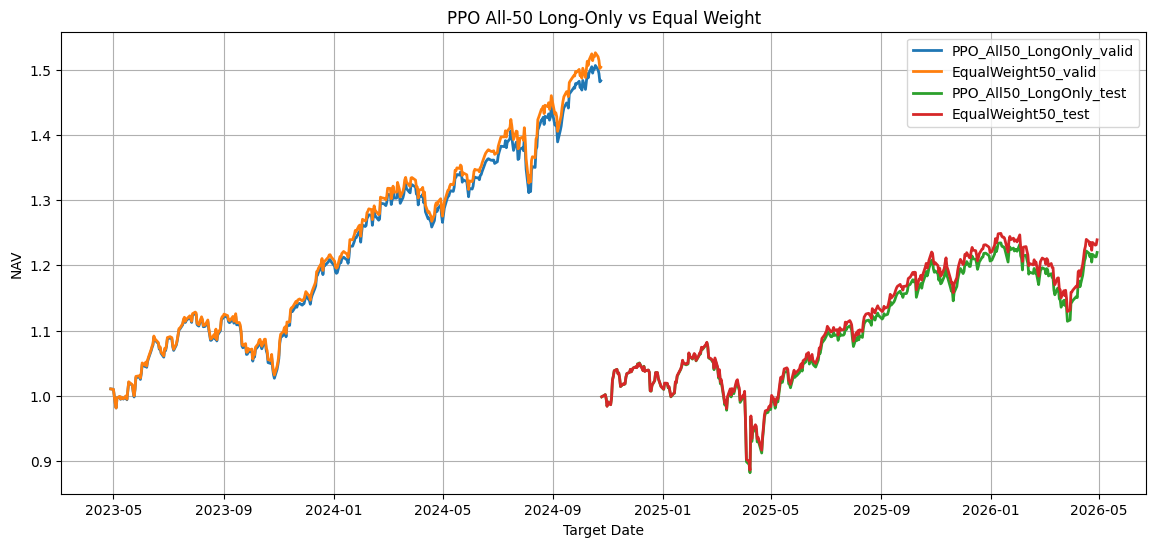

Saved RL summaries, curves, and daily weights to rl_ppo_all50_long_only


In [10]:
def rollout_policy(model, panel, name, deterministic=True):
    env = PortfolioAllocationEnv(panel, cost_bps=COST_BPS)
    obs, _ = env.reset()
    rows = []
    weight_rows = []

    done = False
    while not done:
        action, _ = model.predict(obs, deterministic=deterministic)
        obs, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

        rows.append({
            "date": info["source_date"],
            "target_date": info["target_date"],
            "gross_return": info["gross_return"],
            "turnover": info["turnover"],
            "cost": info["cost"],
            "net_return": info["net_return"],
            "nav": info["nav"],
            "strategy": name,
        })
        for symbol, weight in zip(panel["symbols"], info["weights"]):
            weight_rows.append({
                "date": info["source_date"],
                "target_date": info["target_date"],
                "symbol": symbol,
                "weight": float(weight),
                "strategy": name,
            })

    curve = pd.DataFrame(rows).set_index("target_date").sort_index()
    weights = pd.DataFrame(weight_rows)
    return curve, weights


def equal_weight_backtest(panel, name="EqualWeight50"):
    weights = np.full(len(panel["symbols"]), 1.0 / len(panel["symbols"]), dtype=np.float32)
    rows, weight_rows = [], []
    nav = 1.0
    prev_weights = np.full_like(weights, 1.0 / len(weights))

    for i in range(panel["returns"].shape[0]):
        gross_return = float(np.dot(weights, panel["returns"][i]))
        turnover = float(np.abs(weights - prev_weights).sum())
        cost = turnover * COST_BPS / 10000.0
        net_return = gross_return - cost
        nav *= 1.0 + net_return

        rows.append({
            "date": panel["source_dates"][i],
            "target_date": panel["target_dates"][i],
            "gross_return": gross_return,
            "turnover": turnover,
            "cost": cost,
            "net_return": net_return,
            "nav": nav,
            "strategy": name,
        })
        for symbol, weight in zip(panel["symbols"], weights):
            weight_rows.append({
                "date": panel["source_dates"][i],
                "target_date": panel["target_dates"][i],
                "symbol": symbol,
                "weight": float(weight),
                "strategy": name,
            })
        prev_weights = weights.copy()

    curve = pd.DataFrame(rows).set_index("target_date").sort_index()
    weights_df = pd.DataFrame(weight_rows)
    return curve, weights_df


def metrics(curve, ann_factor=ANN_FACTOR):
    ret = curve["net_return"].dropna()
    n_days = len(ret)
    nav = curve["nav"]
    cummax = nav.cummax()
    drawdown = nav / cummax - 1.0
    total_return = nav.iloc[-1] - 1.0
    ann_return = nav.iloc[-1] ** (ann_factor / n_days) - 1.0
    ann_vol = ret.std(ddof=1) * np.sqrt(ann_factor)
    return {
        "strategy": curve["strategy"].iloc[0],
        "start_date": curve.index.min(),
        "end_date": curve.index.max(),
        "days": n_days,
        "total_return": total_return,
        "ann_return": ann_return,
        "ann_vol": ann_vol,
        "sharpe": ann_return / (ann_vol + 1e-12),
        "max_drawdown": drawdown.min(),
        "win_rate": (ret > 0).mean(),
        "avg_turnover": curve["turnover"].mean(),
        "avg_cost": curve["cost"].mean(),
    }

best_path = os.path.join(MODEL_DIR, "best_model.zip")
if os.path.exists(best_path):
    eval_model = PPO.load(best_path)
    print("Loaded best validation PPO model:", best_path)
else:
    eval_model = model
    print("Using final PPO model.")

valid_ppo_curve, valid_ppo_weights = rollout_policy(eval_model, valid_panel, "PPO_All50_LongOnly_valid")
test_ppo_curve, test_ppo_weights = rollout_policy(eval_model, test_panel, "PPO_All50_LongOnly_test")
valid_eq_curve, valid_eq_weights = equal_weight_backtest(valid_panel, "EqualWeight50_valid")
test_eq_curve, test_eq_weights = equal_weight_backtest(test_panel, "EqualWeight50_test")

summary = pd.DataFrame([
    metrics(valid_ppo_curve),
    metrics(valid_eq_curve),
    metrics(test_ppo_curve),
    metrics(test_eq_curve),
])

display(summary.sort_values(["start_date", "sharpe"], ascending=[True, False]))

plt.figure(figsize=(14, 6))
for curve in [valid_ppo_curve, valid_eq_curve, test_ppo_curve, test_eq_curve]:
    plt.plot(curve.index, curve["nav"], label=curve["strategy"].iloc[0], linewidth=2)
plt.title("PPO All-50 Long-Only vs Equal Weight")
plt.xlabel("Target Date")
plt.ylabel("NAV")
plt.grid(True)
plt.legend()
plt.show()

out_dir = Path("./rl_ppo_all50_long_only")
out_dir.mkdir(exist_ok=True)
summary.to_csv(out_dir / "summary_ppo_vs_equal_weight.csv", index=False)
valid_ppo_curve.to_csv(out_dir / "curve_valid_ppo.csv")
test_ppo_curve.to_csv(out_dir / "curve_test_ppo.csv")
valid_eq_curve.to_csv(out_dir / "curve_valid_equal_weight.csv")
test_eq_curve.to_csv(out_dir / "curve_test_equal_weight.csv")
valid_ppo_weights.to_csv(out_dir / "weights_valid_ppo.csv", index=False)
test_ppo_weights.to_csv(out_dir / "weights_test_ppo.csv", index=False)
print("Saved RL summaries, curves, and daily weights to", out_dir)

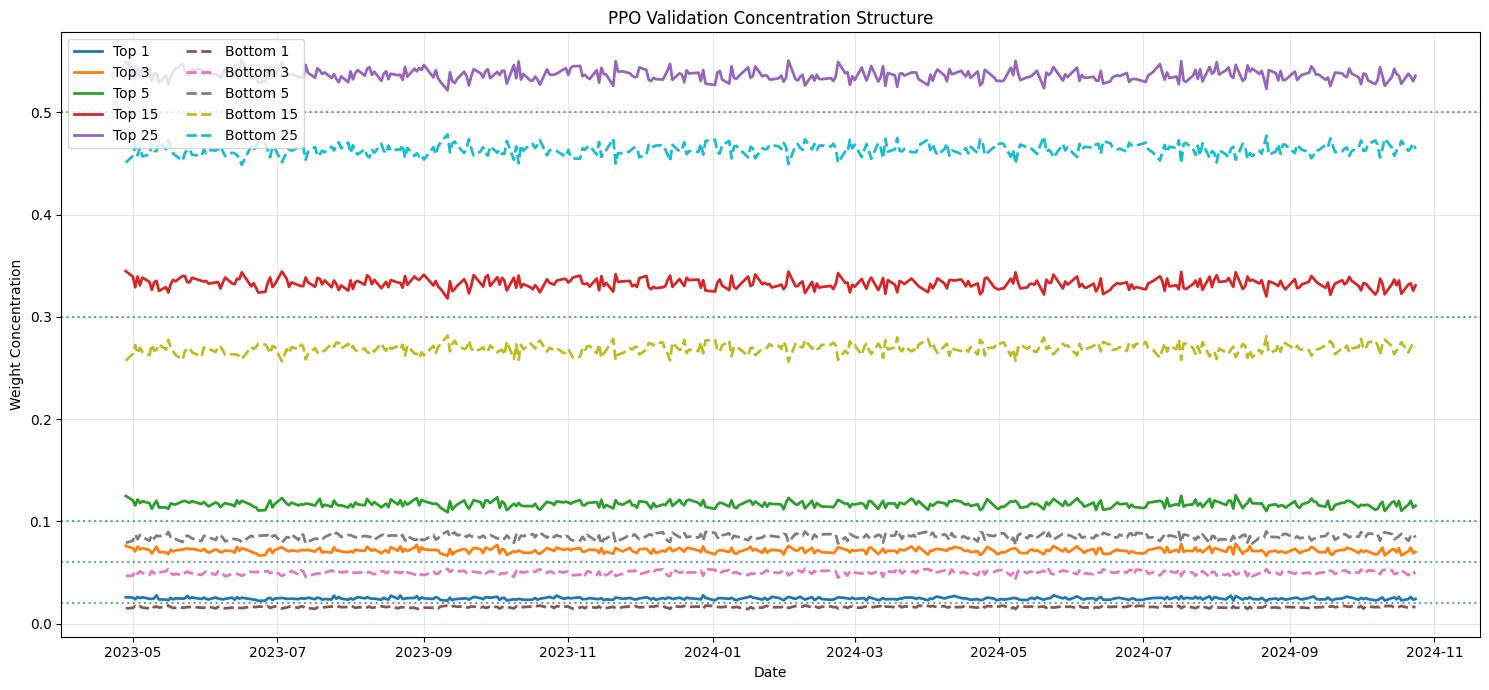

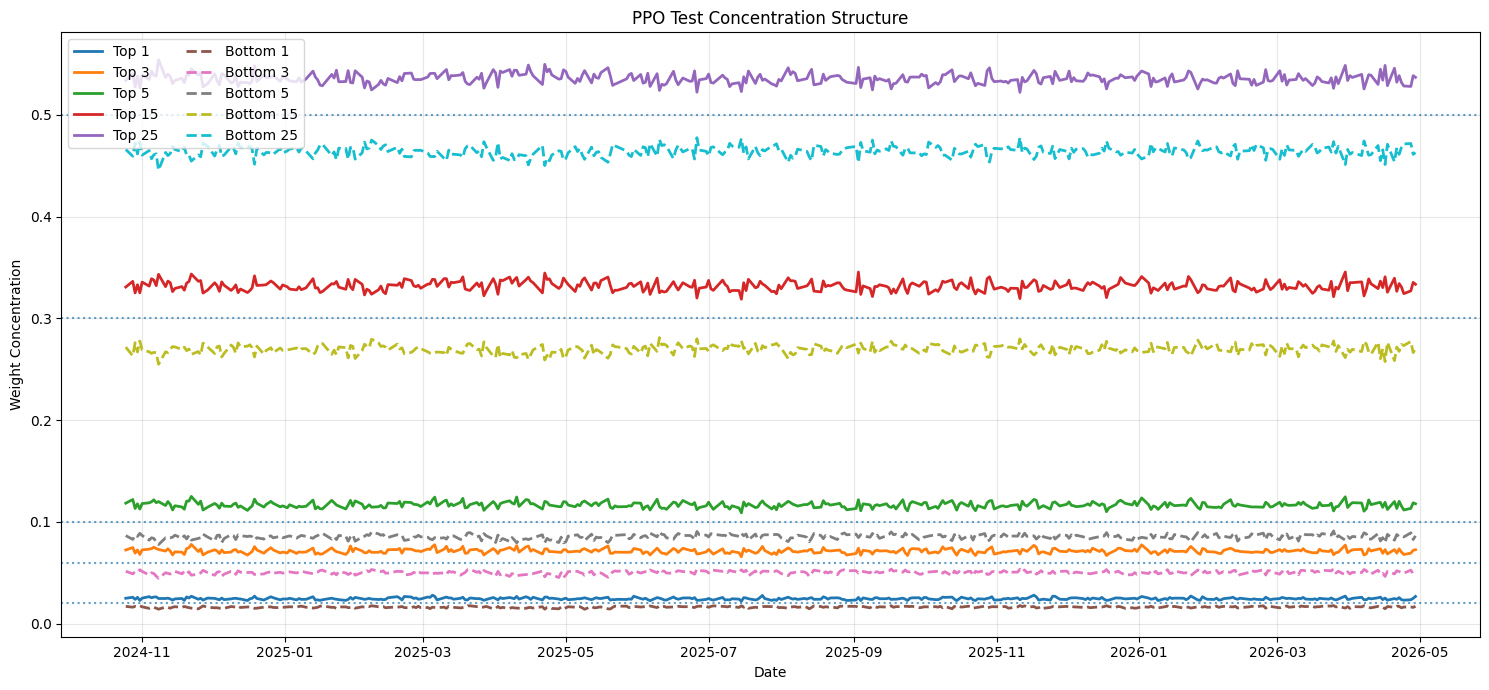

In [ ]:
## Checking to see that the model itself is not equal-weighting 
def compute_concentration(weights_df):
    df = weights_df.copy()

    rows = []

    for date, group in df.groupby("target_date"):
        w = group["weight"].to_numpy()

        w_sorted_desc = np.sort(w)[::-1]
        w_sorted_asc = np.sort(w)

        def safe_sum(arr, k):
            return arr[:k].sum() if len(arr) >= k else arr.sum()

        row = {
            "target_date": date,

            # Top-k
            "top1": w_sorted_desc[0],
            "top3": safe_sum(w_sorted_desc, 3),
            "top5": safe_sum(w_sorted_desc, 5),
            "top15": safe_sum(w_sorted_desc, 15),
            "top25": safe_sum(w_sorted_desc, 25),

            # Bottom-k
            "bottom1": w_sorted_asc[0],
            "bottom3": safe_sum(w_sorted_asc, 3),
            "bottom5": safe_sum(w_sorted_asc, 5),
            "bottom15": safe_sum(w_sorted_asc, 15),
            "bottom25": safe_sum(w_sorted_asc, 25),
        }

        rows.append(row)

    out = pd.DataFrame(rows).sort_values("target_date")
    out["target_date"] = pd.to_datetime(out["target_date"])
    return out.set_index("target_date")

def plot_concentration(conc_df, n_assets=50,
                       title="PPO Portfolio Concentration Over Time"):

    plt.figure(figsize=(15, 7))

    # --- TOP ---
    plt.plot(conc_df.index, conc_df["top1"], label="Top 1", linewidth=2)
    plt.plot(conc_df.index, conc_df["top3"], label="Top 3", linewidth=2)
    plt.plot(conc_df.index, conc_df["top5"], label="Top 5", linewidth=2)
    plt.plot(conc_df.index, conc_df["top15"], label="Top 15", linewidth=2)
    plt.plot(conc_df.index, conc_df["top25"], label="Top 25", linewidth=2)

    # --- BOTTOM ---
    plt.plot(conc_df.index, conc_df["bottom1"], linestyle="--", label="Bottom 1", linewidth=2)
    plt.plot(conc_df.index, conc_df["bottom3"], linestyle="--", label="Bottom 3", linewidth=2)
    plt.plot(conc_df.index, conc_df["bottom5"], linestyle="--", label="Bottom 5", linewidth=2)
    plt.plot(conc_df.index, conc_df["bottom15"], linestyle="--", label="Bottom 15", linewidth=2)
    plt.plot(conc_df.index, conc_df["bottom25"], linestyle="--", label="Bottom 25", linewidth=2)

    # --- Equal-weight reference lines ---
    for k in [1, 3, 5, 15, 25]:
        plt.axhline(k / n_assets, linestyle=":", linewidth=1.5, alpha=0.7)

    plt.title(title)
    plt.xlabel("Date")
    plt.ylabel("Weight Concentration")
    plt.grid(True, alpha=0.3)
    plt.legend(ncol=2)
    plt.tight_layout()
    plt.show()

conc_valid = compute_concentration(valid_ppo_weights)
plot_concentration(conc_valid, n_assets=len(valid_ppo_weights["symbol"].unique()),
                   title="PPO Validation Concentration Structure")

conc_test = compute_concentration(test_ppo_weights)
plot_concentration(conc_test, n_assets=len(test_ppo_weights["symbol"].unique()),
                   title="PPO Test Concentration Structure")